# 1. Ряд. Сумма рядов 

## Определение числового ряда

**Определение 1.**  
Пусть задана бесконечная последовательность чисел

$$
u_1, u_2, \dots, u_n, \dots \tag{1}
$$

Выражение

$$
u_1 + u_2 + \dots + u_n + \dots
$$

называется **числовым рядом**.

Числа $u_1, u_2, \dots, u_n, \dots$ называются **членами ряда**.

---

## Частичные суммы ряда

**Определение 2.**  
Сумма конечного числа первых $n$ членов ряда называется **$n$-й частичной суммой ряда**:

$$
s_n = u_1 + u_2 + \dots + u_n
$$

Рассмотрим первые частичные суммы:

$$
s_1 = u_1
$$

$$
s_2 = u_1 + u_2
$$

$$
s_3 = u_1 + u_2 + u_3
$$

$$
\dots
$$

$$
s_n = u_1 + u_2 + \dots + u_n
$$

---

## Сходимость ряда

Если существует конечный предел

$$
s = \lim_{n \to \infty} s_n
$$

то этот предел называется **суммой ряда**, и говорят, что **ряд сходится**.

Если предел

$$
\lim_{n \to \infty} s_n
$$

не существует (например, если $s_n \to \infty$), то говорят, что **ряд расходится** и суммы не имеет.

---

## Интуитивный смысл

Ряд — это **предел накопления вкладов**.

Мы не складываем бесконечное число членов напрямую.  
Вместо этого мы изучаем **поведение частичных сумм**:

$$
s_1, s_2, s_3, \dots
$$

Если они стремятся к некоторому числу, ряд имеет сумму.

---

# Пример: геометрический ряд

Рассмотрим ряд

$$
a + aq + aq^2 + \dots + aq^{n-1} + \dots \tag{2}
$$

Этот ряд образован членами **геометрической прогрессии**.

- первый член: $a$
- знаменатель: $q$
- предполагается $a \ne 0$

Последовательность считается заданной, если известен закон вычисления любого члена $u_n$.

В данном случае

$$
u_n = a q^{n-1}
$$

---

## Частичная сумма геометрической прогрессии

Сумма первых $n$ членов геометрической прогрессии при $q \ne 1$ равна

$$
s_n = \frac{a - a q^n}{1 - q}
$$

или

$$
s_n = \frac{a}{1-q} - \frac{a q^n}{1-q}
$$

---





# Computational experiments (Python)

Числовые ряды удобно исследовать не напрямую как бесконечные суммы, а через **частичные суммы**.

Для ряда

$$
\sum_{n=1}^{\infty} u_n
$$

мы рассматриваем последовательность частичных сумм

$$
s_n = \sum_{k=1}^{n} u_k
$$

то есть

$$
s_1 = u_1,\quad s_2 = u_1 + u_2,\quad s_3 = u_1 + u_2 + u_3,\dots
$$

Именно по поведению последовательности

$$
s_1, s_2, s_3, \dots
$$

мы судим о сходимости ряда:

- если $s_n$ стремится к конечному пределу, ряд сходится
- если $s_n$ не имеет конечного предела, ряд расходится

Таким образом, задача численного эксперимента состоит в том, чтобы:

1. вычислить первые члены ряда
2. построить их частичные суммы
3. посмотреть, стабилизируются ли они

---

## Пример: геометрический ряд

Рассмотрим геометрический ряд

$$
a + aq + aq^2 + aq^3 + \dots
$$

Его $n$-й член имеет вид

$$
u_n = a q^{n-1}
$$

Если в коде индексация начинается с нуля, то удобно записывать члены ряда как

$$
u_n = a q^n, \quad n = 0,1,2,\dots
$$

Это та же самая геометрическая прогрессия, только сдвинутая по индексу.

---

## Код

In [9]:
import numpy as np

def geometric_series_partial_sums(a, q, N):
    n = np.arange(N)
    terms = a * q**n
    partial_sums = np.cumsum(terms)
    return partial_sums

N = 50
sums = geometric_series_partial_sums(a=1, q=0.5, N=N)

print(sums[:10])

[1.         1.5        1.75       1.875      1.9375     1.96875
 1.984375   1.9921875  1.99609375 1.99804688]



---

## Связь кода с теорией

### 1. `n = np.arange(N)`

Эта строка создаёт массив индексов

```python
[0, 1, 2, ..., N-1]
```

То есть мы берём первые $N$ членов геометрического ряда.

С математической точки зрения это соответствует значениям

$$
n = 0,1,2,\dots,N-1
$$

---

### 2. `terms = a * q**n`

Здесь вычисляются сами члены геометрического ряда:

$$
a,\ aq,\ aq^2,\ aq^3,\dots
$$

Например, если $a=1$ и $q=0.5$, то получится:

$$
1,\ 0.5,\ 0.25,\ 0.125,\dots
$$

То есть массив `terms` — это приближение первых членов бесконечного ряда

$$
\sum_{n=0}^{\infty} aq^n
$$

---

### 3. `partial_sums = np.cumsum(terms)`

Функция `np.cumsum` строит **накопленную сумму** элементов массива.

Если

```python
terms = [u_0, u_1, u_2, u_3, ...]
```

то

```python
np.cumsum(terms)
```

возвращает


$$[u_0,\ u_0+u_1,\ u_0+u_1+u_2,\ u_0+u_1+u_2+u_3, \dots]$$


Это и есть последовательность частичных сумм:

$$
s_1,\ s_2,\ s_3,\dots
$$

Именно этот объект нужен для исследования сходимости ряда.

---

### 4. `return partial_sums`

Функция возвращает массив частичных сумм, то есть численное представление последовательности

$$
s_1, s_2, \dots, s_N
$$

---

### 5. `sums = geometric_series_partial_sums(a=1, q=0.5, N=N)`

Здесь мы берём конкретный геометрический ряд

$$
1 + 0.5 + 0.25 + 0.125 + \dots
$$

Для него выполняется условие

$$
|q| < 1
$$

значит, теоретически ряд должен сходиться.

Его сумма равна

$$
\frac{a}{1-q} = \frac{1}{1-0.5} = 2
$$

Следовательно, мы ожидаем, что частичные суммы будут постепенно приближаться к числу $2$.

---

### 6. `print(sums[:10])`

Эта строка выводит первые 10 частичных сумм.

Примерно получится:

```python
[1.         1.5        1.75       1.875      1.9375
 1.96875    1.984375   1.9921875  1.99609375 1.99804688]
```

Это означает:

$$
s_1 = 1
$$

$$
s_2 = 1 + 0.5 = 1.5
$$

$$
s_3 = 1 + 0.5 + 0.25 = 1.75
$$

$$
s_4 = 1.875
$$

и так далее.

Видно, что частичные суммы всё ближе подходят к числу

$$
2
$$

что подтверждает теоретический результат.

---

## Что показывает этот эксперимент

Этот код демонстрирует основную идею теории рядов:

мы не можем сложить бесконечно много членов напрямую, но можем вычислять всё более длинные частичные суммы и смотреть, к чему они стремятся.

Для геометрического ряда при

$$
|q| < 1
$$

частичные суммы приближаются к

$$
\frac{a}{1-q}
$$

То есть численный эксперимент подтверждает теорему о сходимости геометрического ряда.

---

## Как интерпретировать результат

- если значения `partial_sums` начинают стабилизироваться, это указывает на сходимость
- если они растут без ограничений или колеблются без предела, это указывает на расходимость

Например:

- `q = 0.5` — сходимость
- `q = 0.9` — сходимость, но медленная
- `q = 1` — линейный рост, расходимость
- `q = -1` — колебания, предела нет
- `q = 1.1` — рост без ограничений, расходимость

---

## Вывод

Частичные суммы — это главный вычислительный инструмент для работы с рядами.

В Python их удобно исследовать через:

- генерацию членов ряда
- накопленную сумму `np.cumsum`
- анализ последовательности полученных значений

Это связывает абстрактное определение сходимости ряда с реальным численным экспериментом.

In [10]:
import numpy as np

def geometric_series_partial_sums(a, q, N):
    n = np.arange(N)
    terms = a * q**n
    partial_sums = np.cumsum(terms)
    return partial_sums

N = 50
sums = geometric_series_partial_sums(a=1, q=0.5, N=N)

print(sums[:10])

[1.         1.5        1.75       1.875      1.9375     1.96875
 1.984375   1.9921875  1.99609375 1.99804688]


### Геометрическая интерпретация

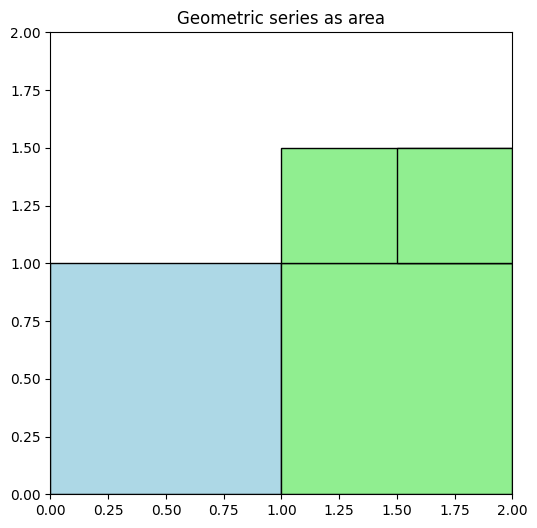

In [11]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

fig, ax = plt.subplots(figsize=(6,6))

# первый квадрат
square = patches.Rectangle((0,0),1,1,edgecolor='black',facecolor='lightblue')
ax.add_patch(square)

# половины
rects = [
    (1,0,1,1),      # 1/2
    (1,1,1,0.5),    # 1/4
    (1.5,1,0.5,0.5),# 1/8
]

for x,y,w,h in rects:
    r = patches.Rectangle((x,y),w,h,edgecolor='black',facecolor='lightgreen')
    ax.add_patch(r)

ax.set_xlim(0,2)
ax.set_ylim(0,2)
ax.set_aspect('equal')

plt.title("Geometric series as area")
plt.show()

# Исследование сходимости

### 1. Случай $|q| < 1$

Если

$$
|q| < 1
$$

то

$$
q^n \to 0 \quad \text{при } n \to \infty
$$

Следовательно

$$
\lim_{n \to \infty} s_n =
\lim_{n \to \infty}
\left(
\frac{a}{1-q} - \frac{a q^n}{1-q}
\right)
=
\frac{a}{1-q}
$$

Таким образом, **ряд сходится**, и его сумма равна

$$
s = \frac{a}{1-q}
$$



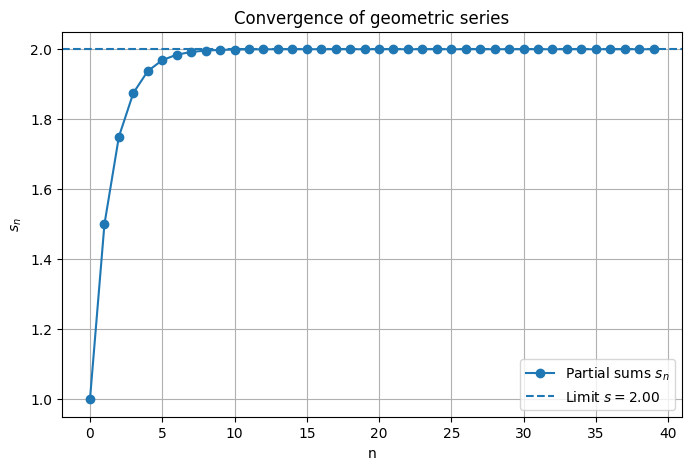

In [12]:
import numpy as np
import matplotlib.pyplot as plt

# параметры ряда
a = 1
q = 0.5
N = 40

# члены ряда
n = np.arange(N)
terms = a * q**n

# частичные суммы
s_n = np.cumsum(terms)

# точная сумма
S = a/(1-q)

# график
plt.figure(figsize=(8,5))

plt.plot(n, s_n, marker='o', label='Partial sums $s_n$')
plt.axhline(S, linestyle='--', label=f'Limit $s = {S:.2f}$')

plt.xlabel("n")
plt.ylabel("$s_n$")
plt.title("Convergence of geometric series")
plt.legend()
plt.grid(True)

plt.show()

### 2. Случай $|q| > 1$

Если

$$
|q| > 1
$$

то

$$
|q^n| \to \infty
$$

и тогда

$$
\frac{a - a q^n}{1-q} \to \pm \infty
$$

Следовательно

$$
\lim_{n \to \infty} s_n
$$

не существует.

В этом случае **ряд расходится**.

---

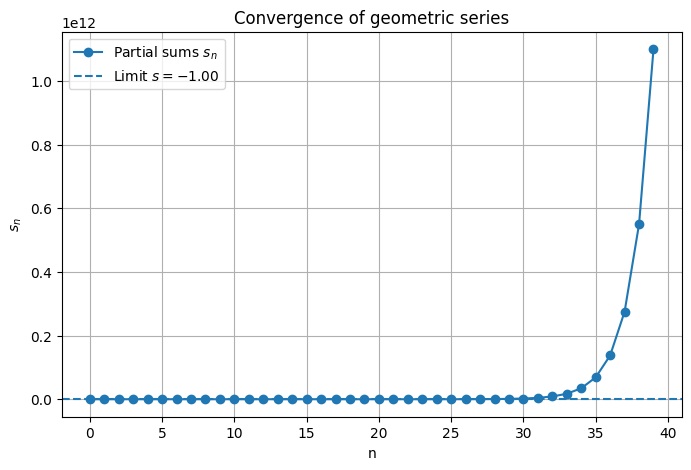

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# параметры ряда
a = 1
q = 2
N = 40

# члены ряда
n = np.arange(N)
terms = a * q**n

# частичные суммы
s_n = np.cumsum(terms)

# точная сумма
S = a/(1-q)

# график
plt.figure(figsize=(8,5))

plt.plot(n, s_n, marker='o', label='Partial sums $s_n$')
plt.axhline(S, linestyle='--', label=f'Limit $s = {S:.2f}$')

plt.xlabel("n")
plt.ylabel("$s_n$")
plt.title("Convergence of geometric series")
plt.legend()
plt.grid(True)

plt.show()

### 3. Случай $q = 1$

Ряд принимает вид

$$
a + a + a + \dots
$$

Тогда

$$
s_n = na
$$

и

$$
\lim_{n \to \infty} s_n = \infty
$$

Следовательно, **ряд расходится**.

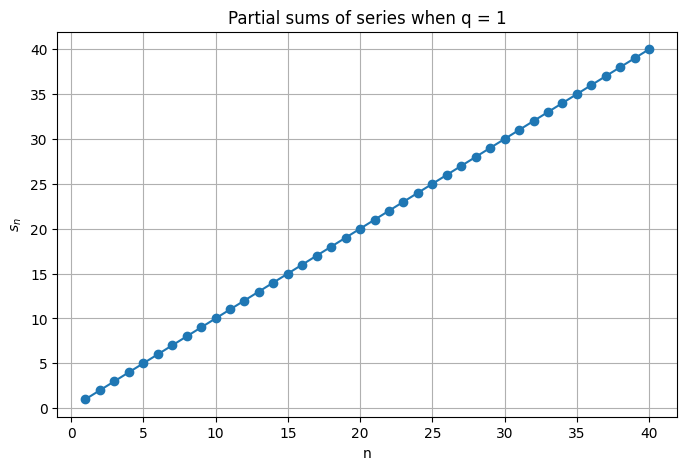

In [14]:
import numpy as np
import matplotlib.pyplot as plt

# параметры
a = 1
N = 40

# индексы
n = np.arange(1, N+1)

# частичные суммы
s_n = a * n

# график
plt.figure(figsize=(8,5))

plt.plot(n, s_n, marker='o')
plt.xlabel("n")
plt.ylabel("$s_n$")
plt.title("Partial sums of series when q = 1")
plt.grid(True)

plt.show()

### 4. Случай $q = -1$

Ряд имеет вид

$$
a - a + a - a + \dots
$$

Частичные суммы принимают значения

$$
s =
\begin{cases}
0, & n \text{ чётное} \\
a, & n \text{ нечётное}
\end{cases}
$$

Последовательность частичных сумм не имеет предела.

Следовательно, **ряд расходится**.

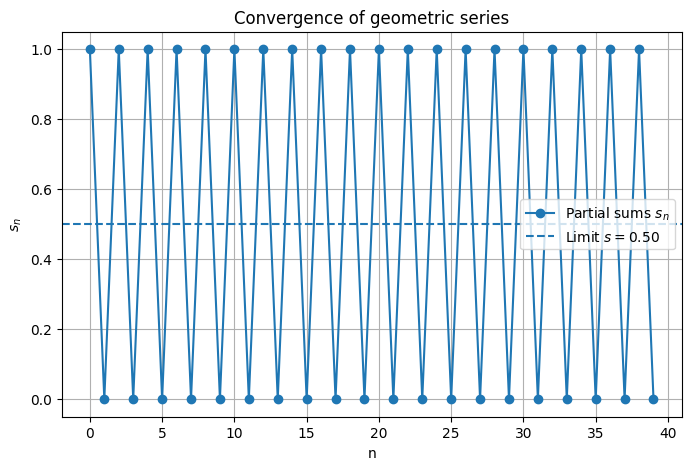

In [15]:
import numpy as np
import matplotlib.pyplot as plt

# параметры ряда
a = 1
q = -1
N = 40

# члены ряда
n = np.arange(N)
terms = a * q**n

# частичные суммы
s_n = np.cumsum(terms)

# точная сумма
S = a/(1-q)

# график
plt.figure(figsize=(8,5))

plt.plot(n, s_n, marker='o', label='Partial sums $s_n$')
plt.axhline(S, linestyle='--', label=f'Limit $s = {S:.2f}$')

plt.xlabel("n")
plt.ylabel("$s_n$")
plt.title("Convergence of geometric series")
plt.legend()
plt.grid(True)

plt.show()

---

## Скорость сходимости геометрического ряда

Для геометрического ряда при $|q| < 1$ частичные суммы стремятся к пределу

$$
s = \frac{a}{1-q}
$$

Полезно изучать не только саму последовательность частичных сумм $s_n$, но и ошибку приближения

$$
|s_n - s|
$$

Для геометрического ряда

$$
s_n = \frac{a}{1-q} - \frac{a q^n}{1-q}
$$

поэтому

$$
|s_n - s| = \left| \frac{a q^n}{1-q} \right|
$$

Следовательно, ошибка убывает как $q^n$, то есть экспоненциально быстро.

На логарифмическом графике это проявляется почти как прямая линия.

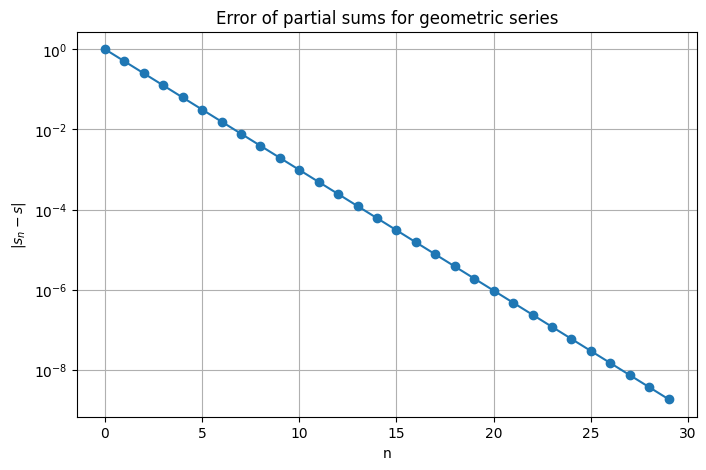

In [16]:
import numpy as np
import matplotlib.pyplot as plt

# параметры
a = 1
q = 0.5
N = 30

# индексы
n = np.arange(N)

# члены ряда
terms = a * q**n

# частичные суммы
s_n = np.cumsum(terms)

# точная сумма
S = a / (1 - q)

# ошибка
error = np.abs(s_n - S)

# график
plt.figure(figsize=(8, 5))
plt.plot(n, error, marker='o')
plt.yscale('log')

plt.xlabel("n")
plt.ylabel(r"$|s_n - s|$")
plt.title("Error of partial sums for geometric series")
plt.grid(True)

plt.show()


---

# Итог

Геометрическая прогрессия (с первым членом, отличным от нуля) **сходится только тогда**, когда

$$
|q| < 1
$$

В этом случае её сумма равна

$$
\sum_{n=0}^{\infty} aq^n = \frac{a}{1-q}
$$

---

## Теорема 1

Если сходится ряд, получившийся из заданного ряда отбрасыванием нескольких его членов, то сходится и сам данный ряд.  
Обратно, если сходится данный ряд, то сходится и ряд, получившийся из заданного отбрасыванием нескольких членов.

**Иными словами:**  
на сходимость ряда не влияет отбрасывание конечного числа его членов.

---

### Интуиция

Сходимость ряда определяется **поведением его хвоста**, то есть членов при больших $n$.

Первые несколько членов образуют просто **конечную сумму**, которая является некоторой константой.  
Добавление или удаление такой константы не влияет на существование предела частичных сумм.

---

## Доказательство

Пусть

$$
s_n
$$

— сумма первых $n$ членов ряда

$$
s_n = u_1 + u_2 + \dots + u_n
$$

Предположим, что мы отбросили первые $k$ членов ряда.

Обозначим

$$
c_k = u_1 + u_2 + \dots + u_k
$$

— сумму отброшенных членов.

Заметим, что $c_k$ — **постоянное число**, не зависящее от $n$.

Теперь рассмотрим сумму остальных членов, входящих в $s_n$, но не входящих в $c_k$:

$$
\sigma_{n-k} = u_{k+1} + u_{k+2} + \dots + u_n
$$

Тогда частичную сумму исходного ряда можно представить в виде

$$
s_n = c_k + \sigma_{n-k}
$$

---

### Анализ пределов

Так как $c_k$ — постоянное число, добавление или вычитание этой константы не влияет на существование предела.

Если существует предел

$$
\lim_{n \to \infty} \sigma_{n-k}
$$

то существует и предел

$$
\lim_{n \to \infty} s_n
$$

поскольку

$$
s_n = c_k + \sigma_{n-k}
$$

И наоборот, если существует предел

$$
\lim_{n \to \infty} s_n
$$

то существует и предел

$$
\lim_{n \to \infty} \sigma_{n-k}
$$

поскольку

$$
\sigma_{n-k} = s_n - c_k
$$

---

### Вывод

Сходимость ряда **не зависит от конечного числа его начальных членов**, а определяется только поведением бесконечного хвоста ряда.

---



## Два простых свойства рядов

### Теорема 2

Если ряд

$$
a_1 + a_2 + \dots \tag{3}
$$

сходится и его сумма равна $s$, то ряд

$$
ca_1 + ca_2 + \dots \tag{4}
$$

где $c$ — некоторое фиксированное число, также сходится, и его сумма равна

$$
cs
$$

---

## Интуиция

Если мы умножим **каждый член ряда** на одно и то же число $c$, то:

- частичные суммы также умножатся на $c$
- предел частичных сумм тоже умножится на $c$

Поэтому новый ряд будет иметь сумму, равную исходной сумме, умноженной на $c$.

---

## Доказательство

Обозначим через

$$
s_n
$$

$n$-ю частичную сумму ряда (3):

$$
s_n = a_1 + a_2 + \dots + a_n
$$

А через

$$
\sigma_n
$$

обозначим $n$-ю частичную сумму ряда (4):

$$
\sigma_n = ca_1 + ca_2 + \dots + ca_n
$$

Вынесем общий множитель $c$:

$$
\sigma_n = c(a_1 + a_2 + \dots + a_n)
$$

Следовательно

$$
\sigma_n = c s_n
$$

---

## Переход к пределу

Так как исходный ряд сходится, существует предел

$$
\lim_{n \to \infty} s_n = s
$$

Тогда

$$
\lim_{n \to \infty} \sigma_n
=
\lim_{n \to \infty} (c s_n)
$$

По свойствам пределов можно вынести постоянный множитель:

$$
\lim_{n \to \infty} (c s_n)
=
c \lim_{n \to \infty} s_n
$$

Следовательно

$$
\lim_{n \to \infty} \sigma_n = cs
$$

---

## Вывод

Ряд

$$
ca_1 + ca_2 + \dots
$$

сходится, и его сумма равна

$$
cs
$$

То есть умножение всех членов сходящегося ряда на постоянное число приводит к умножению суммы ряда на то же число.

---

## Computational experiment

Для этой теоремы можно сделать очень хороший computational experiment, который буквально иллюстрирует формулу из доказательства

$$s_n = c_k + \sigma_{n-k}$$

То есть показать на практике:

- исходные частичные суммы $s_n$
- частичные суммы ряда без первых $k$ членов $\sigma_{n-k}$

и увидеть, что они отличаются ровно на константу $c_k$

1. Эксперимент: геометрический ряд

Возьмём сходящийся ряд

$$\sum^{\infty}_{n=0} q^n$$

например

$$q = 0.5$$

Тогда:

- исходный ряд сходится

- хвост ряда тоже должен сходиться.

In [17]:
import numpy as np
import matplotlib.pyplot as plt

# параметры
q = 0.5
N = 40
k = 5

n = np.arange(N)

# члены ряда
terms = q**n

# частичные суммы исходного ряда
s_n = np.cumsum(terms)

# отбросим первые k членов
tail_terms = terms[k:]

# частичные суммы хвоста
sigma = np.cumsum(tail_terms)

# сумма отброшенных членов
c_k = np.sum(terms[:k])

print("c_k =", c_k)

c_k = 1.9375


3. Проверка формулы из теоремы

По доказательству
	​
$$s_n = c_k + \sigma_{n-k}$$

Проверим это численно.

In [18]:
for i in range(len(sigma)):
    print(s_n[i+k], c_k + sigma[i])

1.96875 1.96875
1.984375 1.984375
1.9921875 1.9921875
1.99609375 1.99609375
1.998046875 1.998046875
1.9990234375 1.9990234375
1.99951171875 1.99951171875
1.999755859375 1.999755859375
1.9998779296875 1.9998779296875
1.99993896484375 1.99993896484375
1.999969482421875 1.999969482421875
1.9999847412109375 1.9999847412109375
1.9999923706054688 1.9999923706054688
1.9999961853027344 1.9999961853027344
1.9999980926513672 1.9999980926513672
1.9999990463256836 1.9999990463256836
1.9999995231628418 1.9999995231628418
1.999999761581421 1.999999761581421
1.9999998807907104 1.9999998807907104
1.9999999403953552 1.9999999403953552
1.9999999701976776 1.9999999701976776
1.9999999850988388 1.9999999850988388
1.9999999925494194 1.9999999925494194
1.9999999962747097 1.9999999962747097
1.9999999981373549 1.9999999981373549
1.9999999990686774 1.9999999990686774
1.9999999995343387 1.9999999995343387
1.9999999997671694 1.9999999997671694
1.9999999998835847 1.9999999998835847
1.9999999999417923 1.99999999994

## Графическая иллюстрация

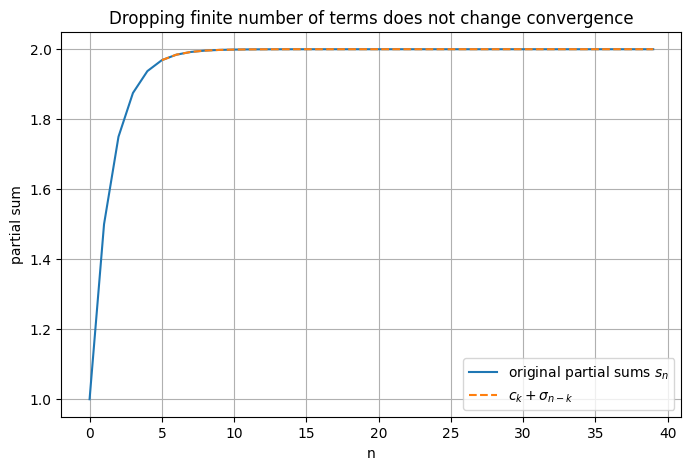

In [19]:
plt.figure(figsize=(8,5))

plt.plot(s_n, label="original partial sums $s_n$")
plt.plot(range(k, N), c_k + sigma, '--', label="$c_k + \\sigma_{n-k}$")

plt.xlabel("n")
plt.ylabel("partial sum")
plt.title("Dropping finite number of terms does not change convergence")
plt.legend()
plt.grid(True)

plt.show()

На графике:

одна линия — исходные частичные суммы

вторая — хвост ряда + константа.

Они совпадают.

Этот эксперимент подтверждает теорему:

если удалить первые $k$ членов ряда, то:

сходимость не изменится

изменится только значение частичных сумм на константу 

То есть:

$$s_n = c_k + \sigma_{n-k}$$

---



### Теорема 3

Если ряды

$$
a_1 + a_2 + \dots \tag{5}
$$

и

$$
b_1 + b_2 + \dots \tag{6}
$$

сходятся и их суммы соответственно равны

$$
\overline{s} \quad \text{и} \quad \overline{\overline{s}},
$$

то ряды

$$
(a_1 + b_1) + (a_2 + b_2) + \dots \tag{7}
$$

и

$$
(a_1 - b_1) + (a_2 - b_2) + \dots \tag{8}
$$

также сходятся, и их суммы соответственно равны

$$
\overline{s} + \overline{\overline{s}}
$$

и

$$
\overline{s} - \overline{\overline{s}}.
$$

---

## Интуиция

Если два ряда сходятся, то их **частичные суммы стремятся к конечным пределам**.

Тогда:

- сумма двух рядов соответствует **сложению их частичных сумм**
- разность рядов соответствует **разности их частичных сумм**

Поскольку предел суммы равен сумме пределов, получаем сходимость нового ряда.

---

## Доказательство

Докажем сходимость ряда (7).

Обозначим:

- через $\sigma_n$ — $n$-ю частичную сумму ряда (7)
- через $\overline{s_n}$ — $n$-ю частичную сумму ряда (5)
- через $\overline{\overline{s}}_n$ — $n$-ю частичную сумму ряда (6)

Тогда

$$
\sigma_n =
(a_1 + b_1) + (a_2 + b_2) + \dots + (a_n + b_n)
$$

Сгруппируем слагаемые:

$$
\sigma_n =
(a_1 + a_2 + \dots + a_n)
+
(b_1 + b_2 + \dots + b_n)
$$

Следовательно

$$
\sigma_n = \overline{s_n} + \overline{\overline{s}}_n
$$

---

## Переход к пределу

Переходим к пределу при $n \to \infty$:

$$
\lim_{n \to \infty} \sigma_n
=
\lim_{n \to \infty}
(\overline{s_n} + \overline{\overline{s}}_n)
$$

По свойствам пределов:

$$
\lim_{n \to \infty} \sigma_n
=
\lim_{n \to \infty} \overline{s_n}
+
\lim_{n \to \infty} \overline{\overline{s}}_n
$$

Так как оба исходных ряда сходятся,

$$
\lim_{n \to \infty} \overline{s_n} = \overline{s}
$$

$$
\lim_{n \to \infty} \overline{\overline{s}}_n = \overline{\overline{s}}
$$

Следовательно

$$
\lim_{n \to \infty} \sigma_n
=
\overline{s} + \overline{\overline{s}}
$$

Таким образом, ряд (7) сходится и его сумма равна

$$
\overline{s} + \overline{\overline{s}}
$$

---

## Ряд разности

Аналогично доказывается, что ряд

$$
(a_1 - b_1) + (a_2 - b_2) + \dots
$$

также сходится и его сумма равна

$$
\overline{s} - \overline{\overline{s}}.
$$

---

## Замечание

Ряды (7) и (8) получены в результате **почленного сложения** и **почленного вычитания** рядов (5) и (6).

---


## Computational illustration of Theorem 3

Теорема утверждает, что если два ряда сходятся, то сходятся и ряды, полученные их почленным сложением и вычитанием.

Численно это можно проверить через **частичные суммы**.

Пусть заданы два ряда

$$
\sum a_n
\quad \text{и} \quad
\sum b_n
$$

Их частичные суммы:

$$
s_n = a_1 + a_2 + \dots + a_n
$$

$$
t_n = b_1 + b_2 + \dots + b_n
$$

Рассмотрим ряд

$$
\sum (a_n + b_n)
$$

Его частичные суммы

$$
\sigma_n = (a_1 + b_1) + (a_2 + b_2) + \dots + (a_n + b_n)
$$

По доказательству теоремы

$$
\sigma_n = s_n + t_n
$$

Проверим это численно.

---

### Python эксперимент

Возьмём два сходящихся геометрических ряда:

$$
a_n = q_1^n
$$

$$
b_n = q_2^n
$$

где

$$
|q_1| < 1, \quad |q_2| < 1
$$

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

N = 50

# параметры рядов
q1 = 0.5
q2 = 0.3

n = np.arange(N)

# члены рядов
a_n = q1**n
b_n = q2**n

# частичные суммы
s_n = np.cumsum(a_n)
t_n = np.cumsum(b_n)

# частичные суммы суммы рядов
sigma_sum = np.cumsum(a_n + b_n)

# частичные суммы разности рядов
sigma_diff = np.cumsum(a_n - b_n)

first 10 values
2.0 2.0
2.8 2.8
3.1399999999999997 3.14
3.292 3.292
3.3625999999999996 3.3626
3.3962799999999995 3.39628
3.4126339999999997 3.4126339999999997
3.4206651999999997 3.4206652
3.42463706 3.4246370600000002
3.426609868 3.426609868


---

### Проверка равенства из теоремы

Проверим численно, что

$$
\sigma_n = s_n + t_n
$$

In [23]:
print("first 10 values")

for i in range(10):
    print(sigma_sum[i], s_n[i] + t_n[i])

first 10 values
2.0 2.0
2.8 2.8
3.1399999999999997 3.14
3.292 3.292
3.3625999999999996 3.3626
3.3962799999999995 3.39628
3.4126339999999997 3.4126339999999997
3.4206651999999997 3.4206652
3.42463706 3.4246370600000002
3.426609868 3.426609868


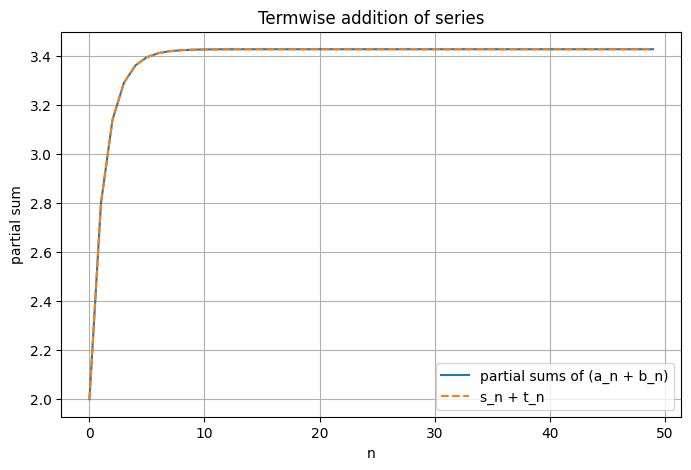

In [24]:
plt.figure(figsize=(8,5))

plt.plot(sigma_sum, label="partial sums of (a_n + b_n)")
plt.plot(s_n + t_n, '--', label="s_n + t_n")

plt.title("Termwise addition of series")
plt.xlabel("n")
plt.ylabel("partial sum")

plt.legend()
plt.grid(True)

plt.show()

На графике видно, что последовательности

$$
\sigma_n
$$

и

$$
s_n + t_n
$$

совпадают.

Это иллюстрирует формулу

$$
\sigma_n = s_n + t_n
$$

и подтверждает теорему о почленном сложении рядов.

---

### Ряд разности

Аналогично можно проверить

$$
\sum (a_n - b_n)
$$

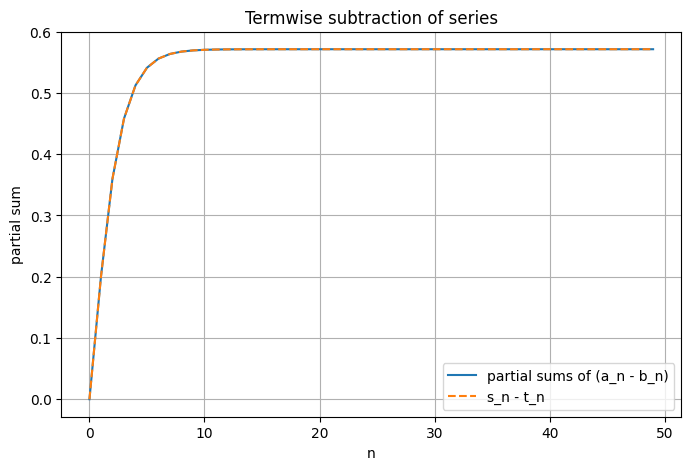

In [25]:
plt.figure(figsize=(8,5))

plt.plot(sigma_diff, label="partial sums of (a_n - b_n)")
plt.plot(s_n - t_n, '--', label="s_n - t_n")

plt.title("Termwise subtraction of series")
plt.xlabel("n")
plt.ylabel("partial sum")

plt.legend()
plt.grid(True)

plt.show()


Таким образом, численный эксперимент подтверждает теорему:

если два ряда сходятся, то сходятся и ряды, полученные их почленным сложением и вычитанием.

---

# ML / Systems / Fintech meaning of series

## 1. Общая идея: накопление вкладов

Ряд

$$
\sum_{n=1}^{\infty} u_n
$$

можно интерпретировать как **накопление последовательных вкладов**.

Частичная сумма

$$
s_n = \sum_{k=1}^{n} u_k
$$

показывает состояние системы после $n$ шагов.

В ML и численных методах многие алгоритмы имеют структуру:

$$
x_{t+1} = x_t + \Delta_t
$$

Развернув итерации, получаем

$$
x_T = x_0 + \sum_{t=1}^{T} \Delta_t
$$

То есть итоговое состояние — это **накопленная сумма обновлений**, аналогичная ряду.

---

# 2. Gradient Boosting

Модель бустинга строится как сумма слабых моделей:

$$
F_M(x) = \sum_{m=1}^{M} \gamma_m h_m(x)
$$

где

- $h_m(x)$ — базовая модель (обычно дерево)
- $\gamma_m$ — коэффициент

Каждая новая модель добавляет **малый вклад**, исправляющий ошибку предыдущих.

Таким образом, boosting можно интерпретировать как **конечный функциональный ряд**.

Связь с теоремой 3:

почленное сложение функций соответствует накоплению вкладов модели.

---

# 3. Итерационные алгоритмы оптимизации

Градиентный спуск:

$$
\theta_{t+1} = \theta_t - \eta \nabla L(\theta_t)
$$

Развернув рекурсию:

$$
\theta_T = \theta_0 - \eta \sum_{t=1}^{T} \nabla L(\theta_t)
$$

То есть итоговый параметр — это **накопленная сумма градиентных обновлений**.

Если обновления уменьшаются, аналогично условию

$$
|q| < 1
$$

в геометрическом ряде, то алгоритм сходится.

---

# 4. Матрический геометрический ряд (очень важная связь)

В линейной алгебре существует аналог геометрического ряда:

$$
I + A + A^2 + A^3 + \dots
$$

Если

$$
\|A\| < 1
$$

то

$$
(I-A)^{-1} = I + A + A^2 + \dots
$$

Это называется **Neumann series**.

Используется в:

- численных методах
- решении линейных систем
- анализе итерационных алгоритмов
- reinforcement learning.

---

# 5. Markov chains

Для марковских процессов важна сумма

$$
\sum_{k=0}^{\infty} P^k
$$

где $P$ — матрица переходов.

Эта сумма используется для вычисления:

- hitting probabilities
- expected visits
- discounted returns.

Это матрический аналог геометрического ряда.

---

# 6. Reinforcement Learning

В RL используется **дисконтированная сумма наград**:

$$
G_t =
\sum_{k=0}^{\infty} \gamma^k R_{t+k}
$$

где

$$
0 < \gamma < 1
$$

Это буквально **геометрически взвешенный ряд**.

Сходимость обеспечивается условием

$$
|\gamma| < 1
$$

что напрямую совпадает с условием сходимости геометрического ряда.

---

# 7. Fintech: discounted cash flows

В финансах часто используется модель дисконтированных платежей.

Стоимость будущих выплат:

$$
V =
\sum_{t=0}^{\infty} \frac{C_t}{(1+r)^t}
$$

где

- $C_t$ — денежный поток
- $r$ — ставка дисконтирования.

Если поток постоянный:

$$
C_t = C
$$

то получаем геометрический ряд

$$
V =
C \sum_{t=0}^{\infty} \left(\frac{1}{1+r}\right)^t
$$

и

$$
V = \frac{C}{r}
$$

Это фундаментальная формула **perpetuity valuation**.

---

# 8. Fintech: risk aggregation

В моделях риска накопленный риск можно представить как сумму вкладов:

$$
R = \sum_{i=1}^{N} r_i
$$

где

$r_i$ — вклад отдельной транзакции или позиции.

Сходимость ряда соответствует **ограниченности суммарного риска**.

---

# 9. Почему важна Теорема 1 (хвост ряда)

Теорема утверждает:

> на сходимость ряда не влияет отбрасывание конечного числа членов.

В ML это означает:

при анализе алгоритма важно **асимптотическое поведение**.

Например:

- первые итерации обучения могут быть шумными
- но долгосрочная динамика определяет сходимость алгоритма.

---

# 10. Главная идея

Ряды — это математическая модель **накопления бесконечного числа малых вкладов**.

Эта идея лежит в основе:

- boosting
- reinforcement learning
- итерационных алгоритмов
- discounted cash flow моделей
- матричных итерационных методов.